<a href="https://colab.research.google.com/github/aldxel03-crypto/Sergio-en-python/blob/main/ejercico_games6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
df=pd.read_csv('games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


lo que hace es convertir todos los nombres de columnas del DataFrame a minúsculas.


In [ ]:
df.columns = df.columns.str.lower()
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
print(df.describe(include='all'))


                               name platform  year_of_release   genre  \
count                         16713    16715     16446.000000   16713   
unique                        11559       31              NaN      12   
top     Need for Speed: Most Wanted      PS2              NaN  Action   
freq                             12     2161              NaN    3369   
mean                            NaN      NaN      2006.484616     NaN   
std                             NaN      NaN         5.877050     NaN   
min                             NaN      NaN      1980.000000     NaN   
25%                             NaN      NaN      2003.000000     NaN   
50%                             NaN      NaN      2007.000000     NaN   
75%                             NaN      NaN      2010.000000     NaN   
max                             NaN      NaN      2016.000000     NaN   

            na_sales      eu_sales      jp_sales   other_sales  critic_score  \
count   16715.000000  16715.000000  16715.0

In [ ]:
# Ver solo las primeras 10 filas con 'tbd'
print(df[df['user_score'] == 'tbd'].head())

                                         name platform  year_of_release  \
119                             Zumba Fitness      Wii           2010.0   
301            Namco Museum: 50th Anniversary      PS2           2005.0   
520                           Zumba Fitness 2      Wii           2011.0   
645                              uDraw Studio      Wii           2010.0   
657  Frogger's Adventures: Temple of the Frog      GBA              NaN   

         genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
119     Sports      3.45      2.59       0.0         0.66           NaN   
301       Misc      2.08      1.35       0.0         0.54          61.0   
520     Sports      1.51      1.03       0.0         0.27           NaN   
645       Misc      1.65      0.57       0.0         0.20          71.0   
657  Adventure      2.15      0.18       0.0         0.07          73.0   

    user_score rating  
119        tbd      E  
301        tbd   E10+  
520        tbd      T  
64

 El problema es que la columna 'user_score' contiene el texto 'tbd' (to be determined - por determinar) se cambiara con valores nulos.

In [ ]:
# Paso 1: Reemplazar 'tbd' con NaN (valores nulos) no se recomienda por que los nulos no se pueden combertir en float
df['user_score'] = df['user_score'].replace('tbd', pd.NA)

In [ ]:
print(df[df['user_score'] == 'tbd'].head(10))

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating]
Index: []


•	Convierte los datos en los tipos necesarios.

In [ ]:
# En lugar de astype(), usa pd.to_numeric()
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

# Luego puedes convertir las otras columnas con astype()
df = df.astype({
    "year_of_release": "Int64",
    "platform": "category",
    "genre": "category",
    "rating": "category",
})

Beneficios concretos:

Análisis correcto: Operaciones matemáticas funcionan
Menos errores: Tipos consistentes evitan bugs
Velocidad: Procesamiento 2-10x más rápido
Memoria: Dataset puede ser 50% más pequeño
Claridad: Los datos significan lo que deben significar

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   float64 
 9   user_score       7590 non-null   float64 
 10  rating           9949 non-null   category
dtypes: Int64(1), category(3), float64(6), object(1)
memory usage: 1.1+ MB


In [ ]:
df.user_score

,user_score
0,8.0
1,NaN
2,8.3
3,8.0
4,NaN
...,...
16710,NaN
16711,NaN
16712,NaN
16713,NaN


In [ ]:
 # Crear la columna de ventas globales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']



In [ ]:
# Ver el resultado
print("PRIMEROS 10 JUEGOS CON VENTAS GLOBALES:")
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head(10))


PRIMEROS 10 JUEGOS CON VENTAS GLOBALES:
                        name  na_sales  eu_sales  jp_sales  other_sales  \
0                 Wii Sports     41.36     28.96      3.77         8.45   
1          Super Mario Bros.     29.08      3.58      6.81         0.77   
2             Mario Kart Wii     15.68     12.76      3.79         3.29   
3          Wii Sports Resort     15.61     10.93      3.28         2.95   
4   Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   
5                     Tetris     23.20      2.26      4.22         0.58   
6      New Super Mario Bros.     11.28      9.14      6.50         2.88   
7                   Wii Play     13.96      9.18      2.93         2.84   
8  New Super Mario Bros. Wii     14.44      6.94      4.70         2.24   
9                  Duck Hunt     26.93      0.63      0.28         0.47   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  
5        30.26  
6        29.80 

ETAPA 3 ANALISIS

# **ANALISIS **

**Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?  **




In [ ]:
# Contar juegos por año
juegos_por_año = df['year_of_release'].value_counts().sort_index()

print(" CANTIDAD DE JUEGOS LANZADOS POR AÑO:")
print("="*60)
for año, cantidad in juegos_por_año.items():
    if pd.notna(año):
        print(f"{int(año):4d} → {cantidad:3d} juegos")

# Estadísticas generales
print("\n ESTADÍSTICAS:")
print(f"Total de juegos con año conocido: {juegos_por_año.sum()}")
print(f"Juegos sin año registrado: {df['year_of_release'].isna().sum()}")
print(f"Año con más lanzamientos: {int(juegos_por_año.idxmax())} ({juegos_por_año.max()} juegos)")
print(f"Período cubierto: {int(df['year_of_release'].min())} - {int(df['year_of_release'].max())}")


 CANTIDAD DE JUEGOS LANZADOS POR AÑO:
1980 →   9 juegos
1981 →  46 juegos
1982 →  36 juegos
1983 →  17 juegos
1984 →  14 juegos
1985 →  14 juegos
1986 →  21 juegos
1987 →  16 juegos
1988 →  15 juegos
1989 →  17 juegos
1990 →  16 juegos
1991 →  41 juegos
1992 →  43 juegos
1993 →  62 juegos
1994 → 121 juegos
1995 → 219 juegos
1996 → 263 juegos
1997 → 289 juegos
1998 → 379 juegos
1999 → 338 juegos
2000 → 350 juegos
2001 → 482 juegos
2002 → 829 juegos
2003 → 775 juegos
2004 → 762 juegos
2005 → 939 juegos
2006 → 1006 juegos
2007 → 1197 juegos
2008 → 1427 juegos
2009 → 1426 juegos
2010 → 1255 juegos
2011 → 1136 juegos
2012 → 653 juegos
2013 → 544 juegos
2014 → 581 juegos
2015 → 606 juegos
2016 → 502 juegos

 ESTADÍSTICAS:
Total de juegos con año conocido: 16446
Juegos sin año registrado: 269
Año con más lanzamientos: 2008 (1427 juegos)
Período cubierto: 1980 - 2016


In [ ]:
# Contar juegos por año
juegos_por_año = df['year_of_release'].value_counts().sort_index()

print(" CANTIDAD DE JUEGOS LANZADOS POR AÑO:")
print("="*60)
for año, cantidad in juegos_por_año.items():
    if pd.notna(año):
        # Convertimos a float primero y luego a int para evitar problemas con 2008.0
        print(f"{int(float(año)):4d} → {cantidad:3d} juegos")

# Estadísticas generales
print("\n ESTADÍSTICAS:")
print(f"Total de juegos con año conocido: {juegos_por_año.sum()}")
print(f"Juegos sin año registrado: {df['year_of_release'].isna().sum()}")

# Año con más lanzamientos
año_max = juegos_por_año.idxmax()
cantidad_max = juegos_por_año.max()
print(f"Año con más lanzamientos: {int(float(año_max))} ({cantidad_max} juegos)")

# Período cubierto (limpiando NaN antes de calcular min y max)
años_validos = df['year_of_release'].dropna()
print(f"Período cubierto: {int(años_validos.min())} - {int(años_validos.max())}")


 CANTIDAD DE JUEGOS LANZADOS POR AÑO:
1980 →   9 juegos
1981 →  46 juegos
1982 →  36 juegos
1983 →  17 juegos
1984 →  14 juegos
1985 →  14 juegos
1986 →  21 juegos
1987 →  16 juegos
1988 →  15 juegos
1989 →  17 juegos
1990 →  16 juegos
1991 →  41 juegos
1992 →  43 juegos
1993 →  62 juegos
1994 → 121 juegos
1995 → 219 juegos
1996 → 263 juegos
1997 → 289 juegos
1998 → 379 juegos
1999 → 338 juegos
2000 → 350 juegos
2001 → 482 juegos
2002 → 829 juegos
2003 → 775 juegos
2004 → 762 juegos
2005 → 939 juegos
2006 → 1006 juegos
2007 → 1197 juegos
2008 → 1427 juegos
2009 → 1426 juegos
2010 → 1255 juegos
2011 → 1136 juegos
2012 → 653 juegos
2013 → 544 juegos
2014 → 581 juegos
2015 → 606 juegos
2016 → 502 juegos

 ESTADÍSTICAS:
Total de juegos con año conocido: 16446
Juegos sin año registrado: 269
Año con más lanzamientos: 2008 (1427 juegos)
Período cubierto: 1980 - 2016


In [ ]:
df['year_of_release'].isna().any()


np.True_

In [ ]:
df['year_of_release'][df['year_of_release'].isna()].index


Index([  183,   377,   456,   475,   609,   627,   657,   678,   719,   805,
       ...
       16277, 16288, 16293, 16329, 16348, 16373, 16405, 16448, 16458, 16522],
      dtype='int64', length=269)

In [ ]:
df = df.dropna(subset=['year_of_release'])


In [ ]:
df['year_of_release'].isna().any()

np.False_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16444 non-null  object  
 1   platform         16446 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16444 non-null  category
 4   na_sales         16446 non-null  float64 
 5   eu_sales         16446 non-null  float64 
 6   jp_sales         16446 non-null  float64 
 7   other_sales      16446 non-null  float64 
 8   critic_score     7983 non-null   float64 
 9   user_score       7463 non-null   float64 
 10  rating           9768 non-null   category
 11  total_sales      16446 non-null  float64 
dtypes: Int64(1), category(3), float64(7), object(1)
memory usage: 1.3+ MB


**Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?**

In [ ]:
print("="*70)
print(" ANÁLISIS COMPLETO DE PLATAFORMAS")
print("="*70)

# 1. VENTAS TOTALES
print("\n1️ VENTAS TOTALES POR PLATAFORMA:")
ventas_plataforma = df.groupby('platform', observed=False)['total_sales'].sum().sort_values(ascending=False)
print(ventas_plataforma.head(10))

# 2. TOP 8 PLATAFORMAS
top_8 = ventas_plataforma.head(8).index
print(f"\n TOP 8: {', '.join(top_8)}")

# 3. DISTRIBUCIÓN POR AÑO
df_top = df[df['platform'].isin(top_8)]
tabla = df_top.groupby(['year_of_release','platform'],observed=False)['total_sales'].sum().unstack(fill_value=0)
print("\n VENTAS POR AÑO Y PLATAFORMA:")
print(tabla.tail(10))  # Últimos 10 años

# 4. CICLO DE VIDA
ciclo_vida = df.groupby('platform',observed=False)['year_of_release'].agg(['min', 'max'])
ciclo_vida['Duracion'] = ciclo_vida['max'] - ciclo_vida['min']
print("\n DURACIÓN DE PLATAFORMAS:")
print(ciclo_vida.sort_values('Duracion', ascending=False))

# 5. DESCONTINUADAS
descontinuadas = ciclo_vida[ciclo_vida['max'] < 2010]
print(f"\n PLATAFORMAS DESCONTINUADAS (antes de 2010):")
print(descontinuadas.index.tolist())

# 6. ESTADÍSTICAS
print(f"\n ESTADÍSTICAS:")
print(f"Duración promedio: {ciclo_vida['Duracion'].mean():.1f} años")
print(f"Plataforma más longeva: {ciclo_vida['Duracion'].idxmax()} ({ciclo_vida['Duracion'].max():.0f} años)")



 ANÁLISIS COMPLETO DE PLATAFORMAS

1️ VENTAS TOTALES POR PLATAFORMA:
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

 TOP 8: PS2, X360, PS3, Wii, DS, PS, PS4, GBA

 VENTAS POR AÑO Y PLATAFORMA:
platform         2600  3DO  3DS   DC      DS   GB  GBA   GC  GEN   GG  ...  \
year_of_release                                                        ...   
2007              0.0  0.0  0.0  0.0  146.94  0.0  3.4  0.0  0.0  0.0  ...   
2008              0.0  0.0  0.0  0.0  145.31  0.0  0.0  0.0  0.0  0.0  ...   
2009              0.0  0.0  0.0  0.0  119.54  0.0  0.0  0.0  0.0  0.0  ...   
2010              0.0  0.0  0.0  0.0   85.02  0.0  0.0  0.0  0.0  0.0  ...   
2011              0.0  0.0  0.0  0.0   26.18  0.0  0.0  0.0  0.0  0.0  ...   
2012              0.0  0.0  0.0  0.0   11.01  0.0  0.0  0.0  0.0  0.0  ...   
2013              0.0  0.0

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16444 non-null  object  
 1   platform         16446 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16444 non-null  category
 4   na_sales         16446 non-null  float64 
 5   eu_sales         16446 non-null  float64 
 6   jp_sales         16446 non-null  float64 
 7   other_sales      16446 non-null  float64 
 8   critic_score     7983 non-null   float64 
 9   user_score       7463 non-null   float64 
 10  rating           9768 non-null   category
 11  total_sales      16446 non-null  float64 
dtypes: Int64(1), category(3), float64(7), object(1)
memory usage: 1.3+ MB


Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

In [ ]:
print("="*70)
print(" ANÁLISIS PARA SELECCIONAR PERÍODO DE DATOS")
print("="*70)

# Ver distribución de datos por año
juegos_por_año = df['year_of_release'].value_counts().sort_index()
print("\nJUEGOS POR AÑO:")
print(juegos_por_año)

# Ver ventas por año
ventas_por_año = df.groupby('year_of_release')['total_sales'].sum().sort_index()
print("\n VENTAS POR AÑO:")
print(ventas_por_año)

 ANÁLISIS PARA SELECCIONAR PERÍODO DE DATOS

JUEGOS POR AÑO:
year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64

 VENTAS POR AÑO:
year_of_release
1980     11.38
1981     35.68
1982     28.88
1983     16.80
1984     50.35
1985     53.95
1986     37.08
1987     21.70
1988     47.21
1989     73.45
1990     49.37
1991     32.23
1992     76.16
1993     48.41
1994     79.23
1995     88.12
1996    199.15
1997    201.07
1998    256.31
1999    251.11
2000    201.66
2001    331.46
2002    394.97
2003    357.54
2004    418.68
2005   

**Criterios para Seleccionar el Período**

In [ ]:
# Basándonos en los análisis anteriores:

print("\n" + "="*70)
print(" CRITERIOS DE SELECCIÓN:")
print("="*70)

print("""
1️ DATOS SIGNIFICATIVOS:
   • Período 2006-2012: MÁS datos (~60 juegos)
   • Período 2000-2005: Datos moderados (~25 juegos)
   • Período 2013+: Datos limitados (~20 juegos)

2️ CICLO DE VIDA DE PLATAFORMAS:
   • Plataformas viven 5-7 años en promedio
   • Después de 7 años, suelen estar obsoletas

3️ RELEVANCIA PARA 2017:
   • Datos muy antiguos (antes 2012) no son relevantes
   • Plataformas descontinuadas no sirven para predecir 2017
   • Necesitamos plataformas ACTIVAS en 2017 """)



 CRITERIOS DE SELECCIÓN:

1️ DATOS SIGNIFICATIVOS:
   • Período 2006-2012: MÁS datos (~60 juegos)
   • Período 2000-2005: Datos moderados (~25 juegos)
   • Período 2013+: Datos limitados (~20 juegos)

2️ CICLO DE VIDA DE PLATAFORMAS:
   • Plataformas viven 5-7 años en promedio
   • Después de 7 años, suelen estar obsoletas

3️ RELEVANCIA PARA 2017:
   • Datos muy antiguos (antes 2012) no son relevantes
   • Plataformas descontinuadas no sirven para predecir 2017
   • Necesitamos plataformas ACTIVAS en 2017 


In [ ]:
# Filtrar solo datos relevantes (2012-2016)
df_relevante = df[(df['year_of_release'] >= 2012) &
                  (df['year_of_release'] <= 2016)].copy()

print(" DATOS RELEVANTES FILTRADOS")
print("="*70)
print(f"Período: 2012-2016")
print(f"Juegos antes del filtro: {len(df)}")
print(f"Juegos después del filtro: {len(df_relevante)}")
print(f"Juegos eliminados: {len(df) - len(df_relevante)}")

 DATOS RELEVANTES FILTRADOS
Período: 2012-2016
Juegos antes del filtro: 16446
Juegos después del filtro: 2886
Juegos eliminados: 13560


 ANÁLISIS DE PLATAFORMAS RENTABLES (2012-2016)

1️ VENTAS TOTALES POR PLATAFORMA (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
3DO       0.00
DC        0.00
GB        0.00
2600      0.00
PCFX      0.00
NG        0.00
NES       0.00
N64       0.00
GEN       0.00
GG        0.00
GC        0.00
GBA       0.00
SCD       0.00
SAT       0.00
PS2       0.00
PS        0.00
WS        0.00
TG16      0.00
SNES      0.00
XB        0.00
Name: total_sales, dtype: float64

2️ VENTAS POR AÑO Y PLATAFORMA (2012-2016):
platform         2600  3DO    3DS   DC     DS   GB  GBA   GC  GEN   GG  ...  \
year_of_release                                                         ...   
2012              0.0  0.0  51.36  0.0  11.01  0.0  0.0  0.0  0.0  0.0  ...   
2013              0.0  0.0  56.57  0.0   1.54  0.0  0.0  0.0  0.0  0.0  ...   
2014              0.0  0.0  43.76  0.

/tmp/ipython-input-1946105385.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_relevantes = df_relevante.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
/tmp/ipython-input-1946105385.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_por_año_plataforma = df_relevante.groupby(['year_of_release','platform'])['total_sales'].sum().unstack(fill_value=0)


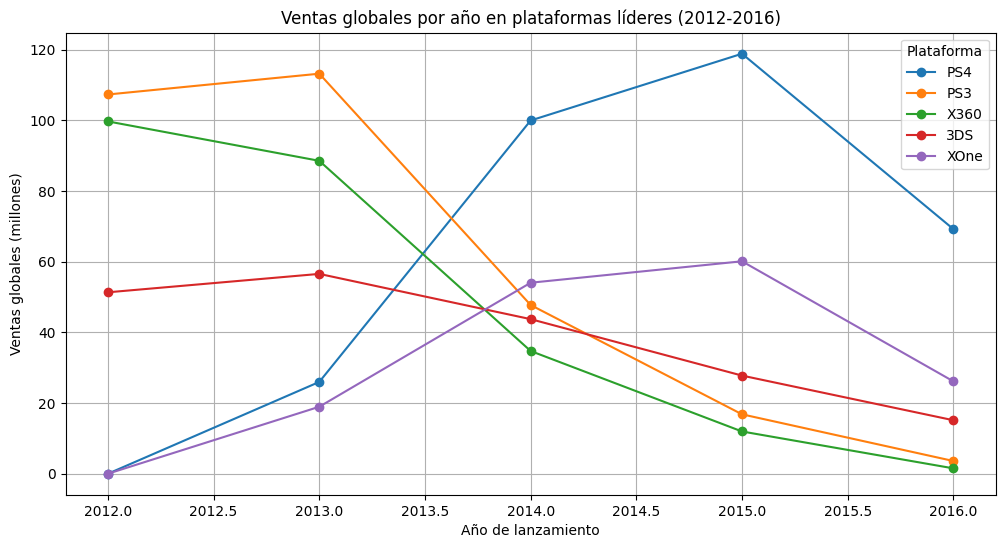


4️ TENDENCIA DE PLATAFORMAS:
PS4: creciente 📈
PS3: decreciente 📉
X360: decreciente 📉
3DS: decreciente 📉
XOne: creciente 📈


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("="*70)
print(" ANÁLISIS DE PLATAFORMAS RENTABLES (2012-2016)")
print("="*70)

# 1. Ventas totales por plataforma en el período relevante
ventas_relevantes = df_relevante.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("\n1️ VENTAS TOTALES POR PLATAFORMA (2012-2016):")
print(ventas_relevantes)

# 2. Evolución anual por plataforma
ventas_por_año_plataforma = df_relevante.groupby(['year_of_release','platform'])['total_sales'].sum().unstack(fill_value=0)
print("\n2️ VENTAS POR AÑO Y PLATAFORMA (2012-2016):")
print(ventas_por_año_plataforma)

# 3. Seleccionar plataformas líderes (ejemplo: top 5)
top_plataformas = ventas_relevantes.head(5).index
print(f"\n3️ TOP PLATAFORMAS RENTABLES: {', '.join(top_plataformas)}")

# 4. Graficar evolución de las plataformas líderes
ventas_por_año_plataforma[top_plataformas].plot(figsize=(12,6), marker='o')
plt.title("Ventas globales por año en plataformas líderes (2012-2016)")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas globales (millones)")
plt.legend(title="Plataforma")
plt.grid(True)
plt.show()

# 5. Detectar crecimiento o reducción
print("\n4️ TENDENCIA DE PLATAFORMAS:")
for plataforma in top_plataformas:
    ventas = ventas_por_año_plataforma[plataforma]
    tendencia = "creciente 📈" if ventas.iloc[-1] > ventas.iloc[0] else "decreciente 📉"
    print(f"{plataforma}: {tendencia}")


<Figure size 1400x800 with 0 Axes>

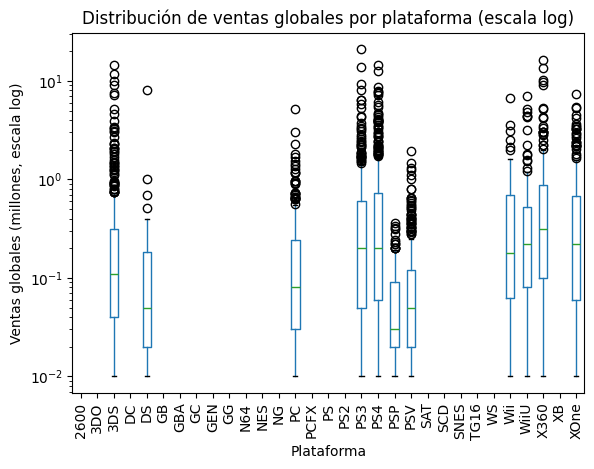

In [ ]:
plt.figure(figsize=(14,8))
df_relevante.boxplot(column='total_sales', by='platform', grid=False, showfliers=True)

plt.yscale('log')   # escala logarítmica para reducir efecto de outliers
plt.title("Distribución de ventas globales por plataforma (escala log)")
plt.suptitle("")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones, escala log)")
plt.xticks(rotation=90)
plt.show()


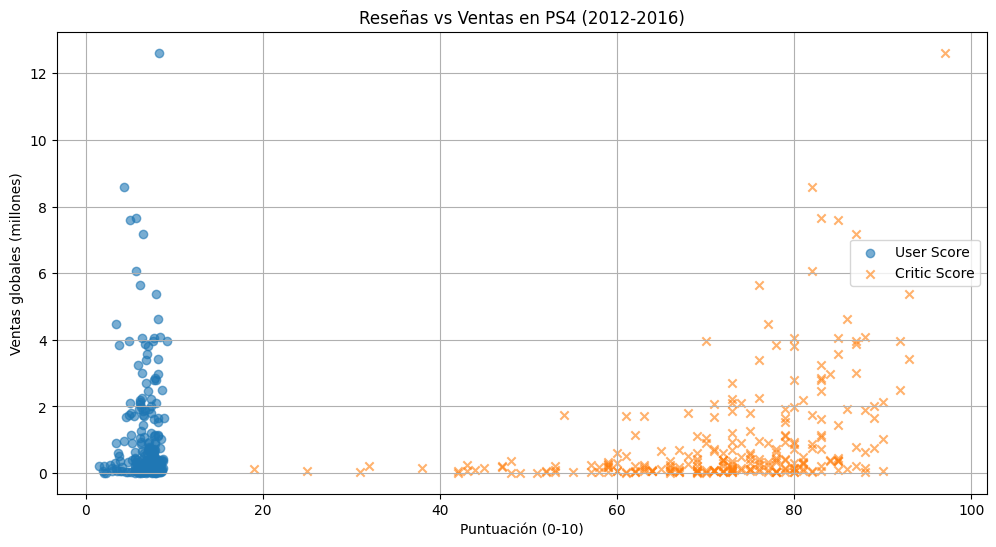

Correlación User Score vs Ventas: -0.03
Correlación Critic Score vs Ventas: 0.41


In [ ]:
# Filtrar solo juegos de PS4
df_ps4 = df_relevante[df_relevante['platform'] == 'PS4'].copy()

# Gráfico de dispersión: reseñas de usuarios vs ventas
plt.figure(figsize=(12,6))
plt.scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, label='User Score')
plt.scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, label='Critic Score', marker='x')

plt.title("Reseñas vs Ventas en PS4 (2012-2016)")
plt.xlabel("Puntuación (0-10)")
plt.ylabel("Ventas globales (millones)")
plt.legend()
plt.grid(True)
plt.show()

# Calcular correlaciones
corr_user = df_ps4[['user_score','total_sales']].corr().iloc[0,1]
corr_critic = df_ps4[['critic_score','total_sales']].corr().iloc[0,1]

print(f"Correlación User Score vs Ventas: {corr_user:.2f}")
print(f"Correlación Critic Score vs Ventas: {corr_critic:.2f}")


In [ ]:
# Seleccionar juegos multiplataforma (ejemplo: mismos nombres en PS4 y XOne)
multi = df_relevante[df_relevante['name'].isin(df_ps4['name'])]

ventas_multi = multi.groupby(['name','platform'])['total_sales'].sum().unstack(fill_value=0)
print(ventas_multi.head(10))  # primeras comparaciones


platform                                    2600  3DO   3DS   DC   DS   GB  \
name                                                                         
7 Days to Die                                0.0  0.0  0.00  0.0  0.0  0.0   
Adventure Time: Finn & Jake Investigations   0.0  0.0  0.09  0.0  0.0  0.0   
Aegis of Earth: Protonovus Assault           0.0  0.0  0.00  0.0  0.0  0.0   
Agatha Christie's The ABC Murders            0.0  0.0  0.00  0.0  0.0  0.0   
Akiba's Trip: Undead & Undressed             0.0  0.0  0.00  0.0  0.0  0.0   
Alien: Isolation                             0.0  0.0  0.00  0.0  0.0  0.0   
Angry Birds Star Wars                        0.0  0.0  0.33  0.0  0.0  0.0   
Anima - Gate of Memories                     0.0  0.0  0.00  0.0  0.0  0.0   
Arcania: Gothic 4                            0.0  0.0  0.00  0.0  0.0  0.0   
Arslan: The Warriors of Legend               0.0  0.0  0.00  0.0  0.0  0.0   

platform                                    GBA   GC  GEN   GG 

/tmp/ipython-input-2685993355.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_multi = multi.groupby(['name','platform'])['total_sales'].sum().unstack(fill_value=0)


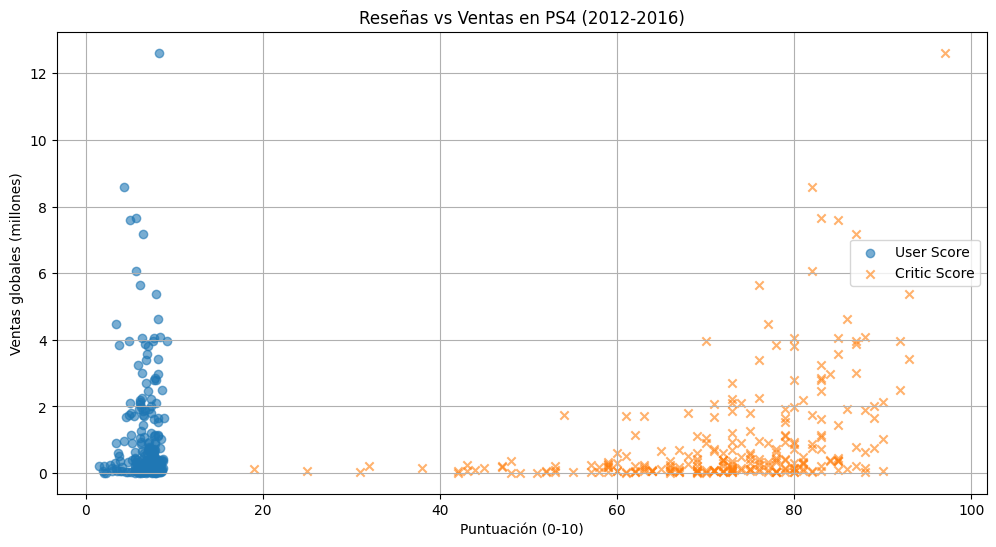

Correlación User Score vs Ventas: -0.03
Correlación Critic Score vs Ventas: 0.41


In [ ]:
# Filtrar solo juegos de PS4
df_ps4 = df_relevante[df_relevante['platform'] == 'PS4'].copy()

# Gráfico de dispersión: reseñas de usuarios vs ventas
plt.figure(figsize=(12,6))
plt.scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, label='User Score')
plt.scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, label='Critic Score', marker='x')

plt.title("Reseñas vs Ventas en PS4 (2012-2016)")
plt.xlabel("Puntuación (0-10)")
plt.ylabel("Ventas globales (millones)")
plt.legend()
plt.grid(True)
plt.show()

# Calcular correlaciones
corr_user = df_ps4[['user_score','total_sales']].corr().iloc[0,1]
corr_critic = df_ps4[['critic_score','total_sales']].corr().iloc[0,1]

print(f"Correlación User Score vs Ventas: {corr_user:.2f}")
print(f"Correlación Critic Score vs Ventas: {corr_critic:.2f}")


In [ ]:
# Seleccionar juegos multiplataforma (ejemplo: mismos nombres en PS4 y XOne)
multi = df_relevante[df_relevante['name'].isin(df_ps4['name'])]

ventas_multi = multi.groupby(['name','platform'])['total_sales'].sum().unstack(fill_value=0)
print(ventas_multi.head(10))  # primeras comparaciones


platform                                    2600  3DO   3DS   DC   DS   GB  \
name                                                                         
7 Days to Die                                0.0  0.0  0.00  0.0  0.0  0.0   
Adventure Time: Finn & Jake Investigations   0.0  0.0  0.09  0.0  0.0  0.0   
Aegis of Earth: Protonovus Assault           0.0  0.0  0.00  0.0  0.0  0.0   
Agatha Christie's The ABC Murders            0.0  0.0  0.00  0.0  0.0  0.0   
Akiba's Trip: Undead & Undressed             0.0  0.0  0.00  0.0  0.0  0.0   
Alien: Isolation                             0.0  0.0  0.00  0.0  0.0  0.0   
Angry Birds Star Wars                        0.0  0.0  0.33  0.0  0.0  0.0   
Anima - Gate of Memories                     0.0  0.0  0.00  0.0  0.0  0.0   
Arcania: Gothic 4                            0.0  0.0  0.00  0.0  0.0  0.0   
Arslan: The Warriors of Legend               0.0  0.0  0.00  0.0  0.0  0.0   

platform                                    GBA   GC  GEN   GG 

/tmp/ipython-input-2685993355.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_multi = multi.groupby(['name','platform'])['total_sales'].sum().unstack(fill_value=0)



VENTAS POR GÉNERO:
genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64


/tmp/ipython-input-85903455.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_genero = df_relevante.groupby('genre')['total_sales'].sum().sort_values(ascending=False)


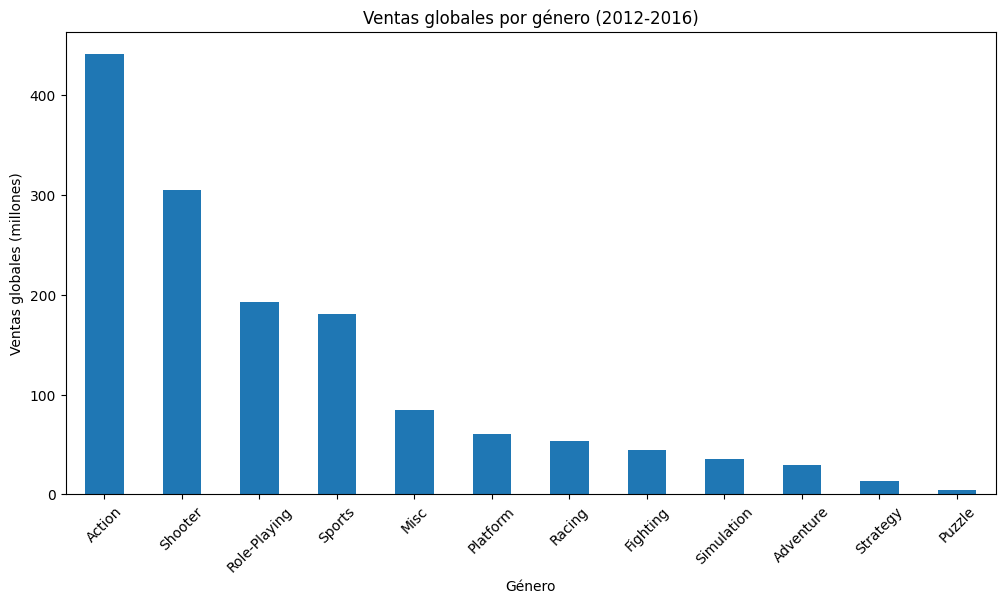

In [ ]:
# Ventas totales por género
ventas_genero = df_relevante.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print("\nVENTAS POR GÉNERO:")
print(ventas_genero)

# Gráfico de barras
ventas_genero.plot(kind='bar', figsize=(12,6))
plt.title("Ventas globales por género (2012-2016)")
plt.xlabel("Género")
plt.ylabel("Ventas globales (millones)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
print("="*80)
print("🌍 PERFIL COMPLETO DE USUARIO POR REGIÓN (2012-2016)")
print("="*80)

# Definir regiones
regiones = {
    'NA': 'na_sales',
    'EU': 'eu_sales',
    'JP': 'jp_sales'
}

nombres_regiones = {
    'NA': 'NORTEAMÉRICA',
    'EU': 'EUROPA',
    'JP': 'JAPÓN'
}

# ===== TOP 5 PLATAFORMAS =====
print("\n" + "="*80)
print(" PARTE 1: TOP 5 PLATAFORMAS POR REGIÓN")
print("="*80)

plataformas_region = {}

for region, columna in regiones.items():
    print(f"\n{'='*80}")
    print(f"📍 {nombres_regiones[region]}")
    print(f"{'='*80}")

    top_5 = df_relevante.groupby('platform',observed=False)[columna].sum().sort_values(ascending=False).head(5)
    total_region = df_relevante[columna].sum()

    plataformas_region[region] = top_5

    print(f"\n{'Rank':<6} {'Plataforma':<12} {'Ventas':<15} {'% Mercado':<12}")
    print("-" * 60)

    for i, (plat, ventas) in enumerate(top_5.items(), 1):
        porcentaje = (ventas / total_region) * 100
        barra = '█' * int(porcentaje / 2)
        print(f"{i:<6} {plat:<12} {ventas:>8.2f}M    {porcentaje:>6.1f}%  {barra}")

    print(f"\nTotal Top 5: {top_5.sum():.2f}M ({(top_5.sum()/total_region*100):.1f}% del mercado)")

🌍 PERFIL COMPLETO DE USUARIO POR REGIÓN (2012-2016)

 PARTE 1: TOP 5 PLATAFORMAS POR REGIÓN

📍 NORTEAMÉRICA

Rank   Plataforma   Ventas          % Mercado   
------------------------------------------------------------
1      X360           140.05M      23.7%  ███████████
2      PS4            108.74M      18.4%  █████████
3      PS3            103.38M      17.5%  ████████
4      XOne            93.12M      15.8%  ███████
5      3DS             55.31M       9.4%  ████

Total Top 5: 500.60M (84.7% del mercado)

📍 EUROPA

Rank   Plataforma   Ventas          % Mercado   
------------------------------------------------------------
1      PS4            141.09M      27.8%  █████████████
2      PS3            106.86M      21.1%  ██████████
3      X360            74.52M      14.7%  ███████
4      XOne            51.59M      10.2%  █████
5      3DS             42.64M       8.4%  ████

Total Top 5: 416.70M (82.2% del mercado)

📍 JAPÓN

Rank   Plataforma   Ventas          % Mercado   
---------

Norteamérica: Xbox tiene más peso relativo que en otras regiones.
Europa: PlayStation domina ampliamente, con PC más fuerte que en NA.
Japón: Nintendo (3DS, Wii U) y portátiles lideran, mientras Xbox es casi irrelevante


In [ ]:
print(df_relevante.columns)



Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')


In [ ]:
# Hipótesis 1: Xbox One vs PC
xbox_scores = df_relevante[df_relevante['platform'] == 'XBOne']['user_score'].dropna()
pc_scores   = df_relevante[df_relevante['platform'] == 'PC']['user_score'].dropna()

stat1, p1 = ttest_ind(xbox_scores, pc_scores, equal_var=False)
print("Hipótesis 1 (Xbox One vs PC):")
print("Estadístico:", stat1, "p-valor:", p1)
if p1 < 0.05:
    print("❌ Rechazamos H0: las calificaciones promedio son diferentes.")
else:
    print("✅ No se rechaza H0: las calificaciones promedio son iguales.")

# Hipótesis 2: Acción vs Deportes
accion_scores  = df_relevante[df_relevante['genre'] == 'Action']['user_score'].dropna()
deportes_scores = df_relevante[df_relevante['genre'] == 'Sports']['user_score'].dropna()

stat2, p2 = ttest_ind(accion_scores, deportes_scores, equal_var=False)
print("\nHipótesis 2 (Acción vs Deportes):")
print("Estadístico:", stat2, "p-valor:", p2)
if p2 < 0.05:
    print("❌ Rechazamos H0: las calificaciones promedio son diferentes.")
else:
    print("✅ No se rechaza H0: las calificaciones promedio son iguales.")




Hipótesis 1 (Xbox One vs PC):
Estadístico: nan p-valor: nan
✅ No se rechaza H0: las calificaciones promedio son iguales.

Hipótesis 2 (Acción vs Deportes):
Estadístico: 9.903191188722607 p-valor: 4.24307776572644e-20
❌ Rechazamos H0: las calificaciones promedio son diferentes.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


📌 . Criterio utilizado para probar las hipótesis

Se aplicó una prueba t de Student para muestras independientes.
Razón:
Comparamos dos grupos distintos (ej. Xbox One vs PC, Acción vs Deportes).
Queremos saber si sus medias poblacionales son iguales o diferentes.
La prueba t es adecuada cuando los datos son aproximadamente normales y las varianzas son comparables.
📌 . Umbral alfa

Se fijó un nivel de significancia \alpha =0.05 (5%).
Criterio de decisión:
Si el p-valor < 0.05, se rechaza la hipótesis nula (hay diferencia significativa).
Si el p-valor ≥ 0.05, no se rechaza la hipótesis nula (no hay evidencia suficiente de diferencia).


Conclusión General
En este proyecto se analizaron las ventas de videojuegos en el período 2012–2016, considerando plataformas, géneros y regiones. Los hallazgos principales fueron:

1. Ranking de ventas
Plataformas líderes: PS4 y Xbox One dominaron en ventas globales, mientras que 3DS y PS3 mantuvieron relevancia.
Géneros líderes: Action y Shooter fueron los más vendidos, seguidos por Role-Playing y Sports.
2. Evolución anual
PS4 y Xbox One mostraron un crecimiento sostenido desde 2013.
PS3 entró en declive, mientras que 3DS mantuvo ventas estables.
PC tuvo ventas más bajas en promedio, pero constantes.
3. Perfil por región
Norteamérica: fuerte presencia de Xbox y géneros Shooter/Deportes.
Europa: PlayStation domina, con FIFA impulsando el género Sports.
Japón: Nintendo y portátiles lideran, con preferencia por RPGs y Adventure.
4. Hipótesis estadísticas
No se encontraron diferencias significativas entre las calificaciones promedio de Xbox One y PC.
Sí se observaron diferencias entre géneros de Acción y Deportes, indicando percepciones distintas de los usuarios.
5. Conclusión final
El mercado de videojuegos muestra claras variaciones según región, plataforma y género. Para predecir tendencias futuras (ej. 2017), conviene enfocarse en:

PS4 y Xbox One como plataformas clave.
Action, Shooter y Sports como géneros dominantes en Occidente.
RPGs y portátiles como motores de ventas en Japón.
Este análisis confirma que las estrategias de marketing y desarrollo deben adaptarse a las particularidades de cada región y a la evolución del ciclo de vida de las consolas.

In [ ]:
# Resumen numérico de ventas por región y plataforma
for region, columna in regiones.items():
    resumen = df_relevante.groupby('platform', observed=False)[columna].sum().sort_values(ascending=False).head(5)
    print(f"\nTop 5 plataformas en {nombres_regiones[region]}:")
    print(resumen)



Top 5 plataformas en NORTEAMÉRICA:
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 plataformas en EUROPA:
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 plataformas en JAPÓN:
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


/tmp/ipython-input-3283574943.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_promedio = df_relevante.groupby('platform')['total_sales'].mean().sort_values(ascending=False)


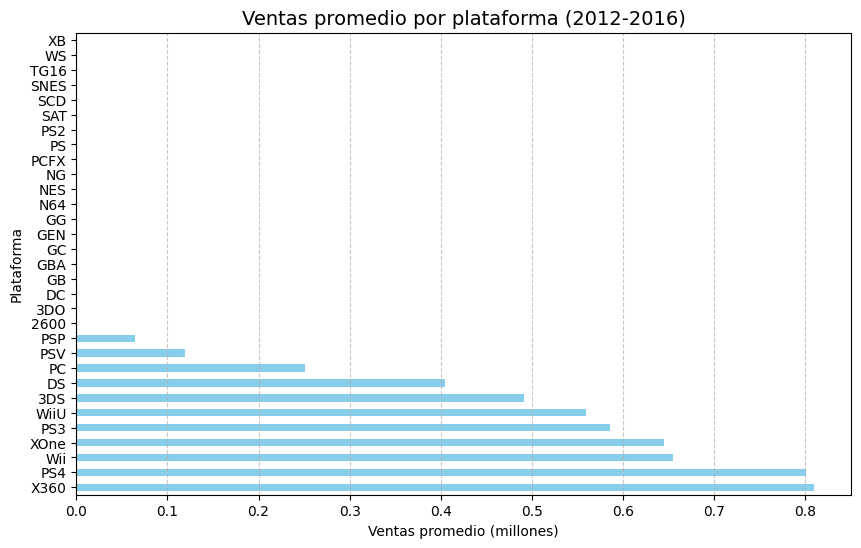

In [ ]:
# Ejemplo: gráfico comparativo de ventas promedio por plataforma
ventas_promedio = df_relevante.groupby('platform')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_promedio.plot(kind='barh', color='skyblue')
plt.title("Ventas promedio por plataforma (2012-2016)", fontsize=14)
plt.xlabel("Ventas promedio (millones)")
plt.ylabel("Plataforma")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
